# Proyecto de Minería de Datos: Captación de Clientes Bancarios

El objetivo del presente trabajo es desarrollar un modelo predictivo que permita estimar si un cliente se convertirá o no en cliente del banco, a partir de variables sociodemográficas, financieras y datos de campañas de marketing.

Paso 2: Importar las librerías necesarias

In [1]:
# Librer?as para manejo de datos
import pandas as pd
import numpy as np

# Librer?as para visualizaci?n
import matplotlib.pyplot as plt

# Librer?as para machine learning
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             classification_report, ConfusionMatrixDisplay,
                             roc_curve, roc_auc_score)

Paso 3: Subir los archivos CSV a Google Colab

In [2]:
from google.colab import files

uploaded = files.upload()

Saving banca_test.csv to banca_test.csv
Saving banca_train.csv to banca_train.csv


Paso 4: Leer los dataset

In [12]:
# Cargar datasets
train = pd.read_csv('banca_train.csv', sep=';')
test = pd.read_csv('banca_test.csv', sep=';')

Paso 5: Verificar que los datos se cargaron correctamente

In [13]:
# Mostrar primeras filas
train.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [14]:
test.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


Paso 6: Analizar la Estructura del Dataset

In [15]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [16]:
train.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


Paso 7: Verificar valores nulos

In [17]:
train.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [18]:
test.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


Paso 8: Analizar la variable objetivo

In [19]:
train['y'].value_counts()

,count
y,
no,39922
yes,5289


In [20]:
train['y'].value_counts(normalize=True) * 100

,proportion
y,
no,88.30152
yes,11.69848


Paso 9: Visualizar la variable objetivo

In [21]:
train.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

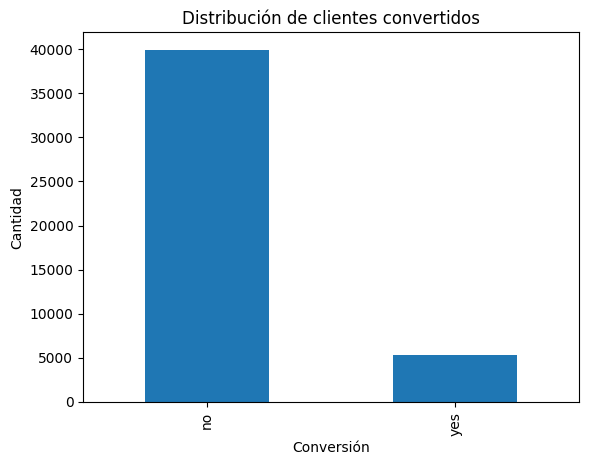

In [22]:
train['y'].value_counts().plot(kind='bar')

plt.title('Distribución de clientes convertidos')
plt.xlabel('Conversión')
plt.ylabel('Cantidad')
plt.show()

Paso 10: Separar variables predictoras y variable objetivo

In [23]:
X_train = train.drop('y', axis=1)
y_train = train['y']

X_test = test.drop('y', axis=1)
y_test = test['y']

Paso 11: Eliminar variable duration (data leakage)

`duration` s?lo se conoce DESPU?S de realizada la llamada telef?nica, por lo que no puede usarse como predictor en un escenario real.

In [ ]:
# Eliminar variable duration (data leakage)
X_train = X_train.drop('duration', axis=1)
X_test  = X_test.drop('duration',  axis=1)

Paso 12: Transformar variables categ?ricas con One-Hot Encoding

Se usa `pd.get_dummies` en lugar de `LabelEncoder` para variables nominales (`job`, `marital`, `education`, etc.). `LabelEncoder` asigna orden impl?cito (0 < 1 < 2) que no existe en estas categor?as. Se concatena train+test antes de aplicar dummies para garantizar las mismas columnas en ambos conjuntos.

In [ ]:
# Concatenar para garantizar columnas id?nticas en train y test
X_total     = pd.concat([X_train, X_test], axis=0)
X_total     = pd.get_dummies(X_total, drop_first=True)
X_train_enc = X_total.iloc[:len(X_train), :]
X_test_enc  = X_total.iloc[len(X_train):,  :]

# Codificar variable objetivo: no -> 0, yes -> 1
le          = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

print(f"Features despu?s de One-Hot Encoding: {X_train_enc.shape[1]}")
X_train_enc.head()

Paso 13: Modelo Base ? ?rbol sin restricciones

Se entrena primero un ?rbol sin l?mite de profundidad para ilustrar el problema de **overfitting**. Con `max_depth=None` el ?rbol crece hasta memorizar todos los datos de entrenamiento.

In [ ]:
modelo_base = DecisionTreeClassifier(random_state=42)
modelo_base.fit(X_train_enc, y_train_enc)
y_pred_base = modelo_base.predict(X_test_enc)

print(f"Profundidad del ?rbol: {modelo_base.get_depth()}")
print(f"Accuracy (modelo base): {accuracy_score(y_test_enc, y_pred_base):.4f}")
print("ADVERTENCIA: Accuracy = 1.0 indica overfitting ? el ?rbol memoriz? el dataset")

Paso 14: Entrenar el modelo controlado ? CART (Gini)

Se incorporan tres correcciones clave:
- `max_depth=5`: limita la profundidad para evitar memorizaci?n
- `min_samples_leaf=20`: cada hoja debe tener al menos 20 muestras
- `class_weight='balanced'`: compensa el desbalance 88% No / 12% S?, ponderando m?s los errores en la clase minoritaria

In [ ]:
# Modelo CART con criterio Gini
modelo = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=20,
    class_weight='balanced',
    random_state=42
)
modelo.fit(X_train_enc, y_train_enc)
print(f"Profundidad real del ?rbol: {modelo.get_depth()}")

Paso 15: Realizar predicciones

In [ ]:
y_pred = modelo.predict(X_test_enc)
y_prob = modelo.predict_proba(X_test_enc)[:, 1]

Paso 16: Crear y visualizar la matriz de confusi?n

In [ ]:
cm = confusion_matrix(y_test_enc, y_pred)
print("Matriz de confusi?n:\n", cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'S?'])
disp.plot(cmap='Blues', colorbar=False)
plt.title('Matriz de Confusi?n ? Modelo Controlado (sin duration)')
plt.tight_layout()
plt.show()

Paso 17: Calcular el Accuracy del modelo

In [ ]:
accuracy = accuracy_score(y_test_enc, y_pred)
print("Accuracy del modelo:", accuracy)

Paso 18: Obtener m?tricas completas

Con datos desbalanceados (88% / 12%), el **F1-score** y el **AUC-ROC** son m?tricas m?s representativas que el accuracy s?lo.

In [ ]:
print(classification_report(y_test_enc, y_pred, target_names=['No', 'S?']))

Paso 19: Calcular curva ROC y AUC

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test_enc, y_prob)
auc = roc_auc_score(y_test_enc, y_prob)
print("AUC:", auc)

Paso 20: Graficar la Curva ROC

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#3b82f6', lw=2, label=f'ROC Curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC ? Modelo Controlado (CART)')
plt.legend()
plt.tight_layout()
plt.show()

Paso 21: Importancia de variables

In [ ]:
feat_imp = pd.Series(modelo.feature_importances_, index=X_train_enc.columns)
feat_imp.sort_values(ascending=True).tail(15).plot(
    kind='barh', figsize=(8, 5), color='#3b82f6')
plt.title('Top 15 Variables m?s importantes')
plt.xlabel('Importancia (Gini)')
plt.tight_layout()
plt.show()